# SciPy Bootcamp — Week 1, Day 7
```
##### Monte Carlo Simulation
##### Simulation, uncertainty quantification, bootstrapping, A/B test power
##### Dataset: Simulated MedPulse subscription and Healthline campaign data
##### No external dataset needed — Monte Carlo generates its own data
##### Q1 Estimate π: use Monte Carlo simulation with 1,000,000 random points in a unit square to estimate π. Print your estimate and the error vs the true value. Then show how the estimate converges as you increase from 1,000 to 1,000,000 points by printing estimates at 1k, 10k, 100k, 1M.
##### Q2 Revenue projection simulation: MedPulse digital subscriptions — simulate 12 monthly revenue figures where: monthly_new_subs ~ Normal(4500, 600), churn_rate ~ Beta(2,20) ≈ 9%, price_per_sub ~ Normal(17.50, 1.50). Run 50,000 simulations of annual revenue. Print mean, std, 5th percentile (downside), 95th percentile (upside), and P(annual revenue > $9M).
##### Q3 A/B test power simulation: Healthline is testing a new article layout. Baseline CTR is 8%. You want 80% power to detect a 1.5pp lift (to 9.5%) at α=0.05. Use Monte Carlo to empirically estimate the required sample size per group by simulating 2,000 tests at each of n=500, 1000, 2000, 3000, 5000. Print empirical power at each n.
##### Q4 Bootstrap confidence intervals: from a sample of 30 Healthline user satisfaction scores (generate from np.random.normal(7.2, 1.5, 30)), compute 95% bootstrap CIs for: (a) the mean, (b) the median, (c) the 90th percentile. Use 10,000 bootstrap samples. Print all three CIs and explain why bootstrapping is useful for the 90th percentile specifically.
##### Q5 Risk simulation — editorial planning: MedPulse publishes 5 digital articles per day. Each article has: views ~ Lognormal(mu=8, sigma=1.2), ad_revenue_per_1000_views ~ Normal(4.50, 0.80). Simulate 365 days of operation (10,000 simulations). Print: expected annual ad revenue, probability of a day with total views > 500k, and the 10th percentile of daily revenue (the 'bad day' scenario).

In [45]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [ ]:
# Q1 Estimate π: 
# use Monte Carlo simulation with 1,000,000 random points in a unit square to estimate π. 
# Print your estimate and the error vs the true value.
#  Then show how the estimate converges as you increase from 1,000 to 1,000,000 points by printing estimates at 1k, 10k, 100k, 1M.

In [4]:
np.random.seed(420)
N = 1000000   # number of simulations

# Example: Estimate π using random points in a unit square
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)
inside_circle = (x**2 + y**2) <= 1
pi_estimate = 4 * inside_circle.sum() / N
print(f'Estimated π: {pi_estimate:.4f}')   # Should be close to 3.1416
print(f'Error: {np.abs(pi_estimate - 3.1416):.4f}')


Estimated π: 3.1423
Error: 0.0007


In [ ]:
np.random.seed(420)
N = [1000, 10000, 100000, 1000000]   # number of simulations

# Example: Estimate π using random points in a unit square
for n in N:
    x = np.random.uniform(0, 1, n)
    y = np.random.uniform(0, 1, n)
    inside_circle = (x**2 + y**2) <= 1
    pi_estimate = 4 * inside_circle.sum() / n
    print(f'For n = {n} -> Estimated π: {pi_estimate:.4f} and Error: {np.abs(pi_estimate - 3.1416):.4f}')   # Should be close to 3.1416

# Monte Carlo error shrinks by roughly √10 each time we 10x the sample sizes

For n = 1000 -> Estimated π: 3.2040 and Error: 0.0624
For n = 10000 -> Estimated π: 3.1672 and Error: 0.0256
For n = 100000 -> Estimated π: 3.1471 and Error: 0.0055
For n = 1000000 -> Estimated π: 3.1419 and Error: 0.0003


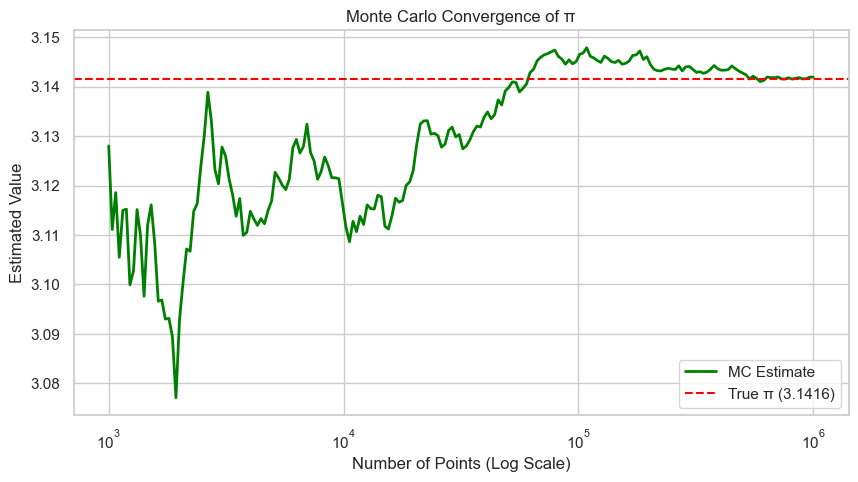

In [53]:
# plotting
N_max = 1_000_000
point_sizes = np.geomspace(1000, N_max, 200).astype(int)
estimates = [4 * np.sum(inside_circle[:n]) / n for n in point_sizes]

plt.figure(figsize=(10, 5))

sns.lineplot(x=point_sizes, y=estimates, color="green", linewidth=2, label="MC Estimate")

plt.axhline(y=np.pi, color="red", linestyle="--", linewidth=1.5, label=f"True π ({np.pi:.4f})")

plt.title("Monte Carlo Convergence of π")
plt.xlabel("Number of Points (Log Scale)")
plt.ylabel("Estimated Value")
plt.xscale("log") # Log scale is crucial for this visual!
plt.legend()
plt.show()

In [ ]:
# Q2 Revenue projection simulation: 
# MedPulse digital subscriptions — simulate 12 monthly revenue figures where: 
# monthly_new_subs ~ Normal(4500, 600), 
# churn_rate ~ Beta(2,20) ≈ 9%, 
# price_per_sub ~ Normal(17.50, 1.50). 
# Run 50,000 simulations of annual revenue. 
# Print mean, std, 5th percentile (downside), 95th percentile (upside), and P(annual revenue > $9M).

In [41]:
np.random.seed(420)
N = 50000
months = 12
starting_subs = 10000 

# Uncertain inputs — each drawn from a distribution
new_subs = np.random.normal(loc=4500, scale=600, size=(N, months))
churn_rate = np.random.beta(a=2, b=20, size=(N, months))   # ~9% 
price = np.random.normal(loc=17.5, scale=1.5, size=(N, months))

# Step through time to compound subscribers
subs_matrix = np.zeros((N, months))
current_subs = np.full(N, starting_subs)

for m in range(months):
    # Apply churn and add new acquisitions
    current_subs = (current_subs * (1 - churn_rate[:, m])) + new_subs[:, m]
    subs_matrix[:, m] = current_subs

# Calculate total annual revenue per simulation
monthly_revenue = subs_matrix * price
annual_revenue = monthly_revenue.sum(axis=1)

# Summary
print(f'Mean Annual Revenue:  ${np.mean(annual_revenue):,.0f}')
print(f'Annual Std Dev:      ${np.std(annual_revenue):,.0f}')
print(f'5th percentile:      ${np.percentile(annual_revenue, 5):,.0f} (downside)')
print(f'95th percentile:     ${np.percentile(annual_revenue, 95):,.0f} (upside)')
print(f'P(revenue > $9M):    {(annual_revenue > 9000000).mean():.2%}')

Mean Annual Revenue:  $5,685,017
Annual Std Dev:      $458,364
5th percentile:      $4,936,004 (downside)
95th percentile:     $6,445,915 (upside)
P(revenue > $9M):    0.00%


In [ ]:
# Q3 A/B test power simulation: 
# Healthline is testing a new article layout. 
# Baseline CTR is 8%. 
# You want 80% power to detect a 1.5pp lift (to 9.5%) at α=0.05. 
# Use Monte Carlo to empirically estimate the required sample size per group by simulating 2,000 tests at each of n=500, 1000, 2000, 3000, 5000. 
# Print empirical power at each n.

In [26]:
# Traditional formula approach
np.random.seed(420)
baseline_rate = 0.08   # current 8% click rate
lift          = 0.015   # we want to detect a 1.5pp lift
alpha         = 0.05
power         = 0.80

# Monte Carlo approach — simulate the experiment many times
def simulate_ab_test(n_per_group, baseline, lift, n_sims=2000):
    significant = 0
    for _ in range(n_sims):
        control  = np.random.binomial(n_per_group, baseline)
        treatment = np.random.binomial(n_per_group, baseline + lift)
        _, p = stats.chi2_contingency([[control, n_per_group - control],
                                       [treatment, n_per_group - treatment]])[:2]
        if p < alpha:
            significant += 1
    return significant / n_sims   # empirical power

# Test different sample sizes
for n in [500, 1000, 2000, 3000, 5000, 10000]:
    power_est = simulate_ab_test(n, baseline_rate, lift, n_sims=2000)
    print(f'n={n:5d} per group → empirical power: {power_est:.2%}')

n=  500 per group → empirical power: 11.75%
n= 1000 per group → empirical power: 18.75%
n= 2000 per group → empirical power: 33.35%
n= 3000 per group → empirical power: 50.95%
n= 5000 per group → empirical power: 74.90%
n=10000 per group → empirical power: 95.95%


In [ ]:
# Q4 Bootstrap confidence intervals: 
# from a sample of 30 Healthline user satisfaction scores (generate from np.random.normal(7.2, 1.5, 30)),
#  compute 95% bootstrap CIs for: (a) the mean, (b) the median, (c) the 90th percentile. 
# Use 10,000 bootstrap samples. 
# Print all three CIs and explain why bootstrapping is useful for the 90th percentile specifically.

In [42]:
np.random.seed(420)
satisfaction_scores = np.random.normal(7.2, 1.5, 30)
n_boot = 10000

# a. mean
boot_means = [
    np.mean(np.random.choice(satisfaction_scores, len(satisfaction_scores), replace=True))
    for _ in range(n_boot)
]

ci = np.percentile(boot_means, [2.5, 97.5])
print(f'Observed mean: {np.mean(satisfaction_scores):.2f}')
print(f'95% Bootstrap CI: ({ci[0]:.2f}, {ci[1]:.2f})')
print()

# b. median
boot_medians = [
    np.median(np.random.choice(satisfaction_scores, len(satisfaction_scores), replace=True))
    for _ in range(n_boot)
]

ci = np.percentile(boot_medians, [2.5, 97.5])
print(f'Observed median: {np.median(satisfaction_scores):.2f}')
print(f'95% Bootstrap CI: ({ci[0]:.2f}, {ci[1]:.2f})')
print()


# b. 90% percentile
ninety_pctile = [
    np.quantile(np.random.choice(satisfaction_scores, len(satisfaction_scores), replace=True), 0.9)
    for _ in range(n_boot)
]

ci = np.percentile(ninety_pctile, [2.5, 97.5])
print(f'Observed Ninety Percentile: {np.quantile(satisfaction_scores, 0.9):.2f}')
print(f'95% Bootstrap CI: ({ci[0]:.2f}, {ci[1]:.2f})')

Observed mean: 7.00
95% Bootstrap CI: (6.44, 7.57)

Observed median: 6.70
95% Bootstrap CI: (6.35, 7.87)

Observed Ninety Percentile: 9.17
95% Bootstrap CI: (8.26, 9.54)


```
Why bootstrapping is useful for the 90th percentile specifically?
- No simple formulas: Unlike the mean, extreme percentiles have no standard textbook formulas to calculate confidence intervals.
- Distribution independent: It does not require assuming the data is perfectly bell-curved, letting the actual data dictate the shape.
- Handles small samples: Extreme percentiles are highly unstable in small datasets (like N<=30), and bootstrapping accurately reveals this high volatility.- Reveals skewness: It maps out the actual asymmetric real-world risk at the tails of the data.

In [ ]:
# Q5 Risk simulation — editorial planning: 
# MedPulse publishes 5 digital articles per day. 
# Each article has: 
# views ~ Lognormal(mu=11, sigma=1.2), 
# ad_revenue_per_1000_views ~ Normal(4.50, 0.80). 
# Simulate 365 days of operation (10,000 simulations). 
# Print: 
# expected annual ad revenue,
# probability of a day with total views > 500k, 
# and the 10th percentile of daily revenue (the 'bad day' scenario).

In [43]:
np.random.seed(420)
N = 10000
days = 365
articles_per_day = 5

# Simulate views for 5 articles x 365 days across 10,000 runs
# Shape is (10000, 365, 5)
views = np.random.lognormal(mean=11, sigma=1.2, size=(N, days, articles_per_day))


# Sum the views of the 5 articles to get total daily views
total_daily_views = views.sum(axis=2) # Shape drops to (10000, 365)

# Simulate ad RPM (Revenue Per Mille / 1000 views) for each day
# Shape is (10000, 365)
rpm = np.random.normal(loc=4.50, scale=0.80, size=(N, days))

# Calculate Daily and Annual Revenue
daily_revenue = (total_daily_views / 1000) * rpm
annual_revenue = daily_revenue.sum(axis=1) # Sum across 365 days

# Summary Output
print(f'Expected annual ad revenue:  ${np.mean(annual_revenue):,.0f}')
print(f'P(Daily views > 500k):       {(total_daily_views > 500000).mean():.4%}')
print(f'10th pct daily revenue:      ${np.percentile(daily_revenue, 10):,.2f}')

Expected annual ad revenue:  $1,010,324
P(Daily views > 500k):       48.3279%
10th pct daily revenue:      $956.25


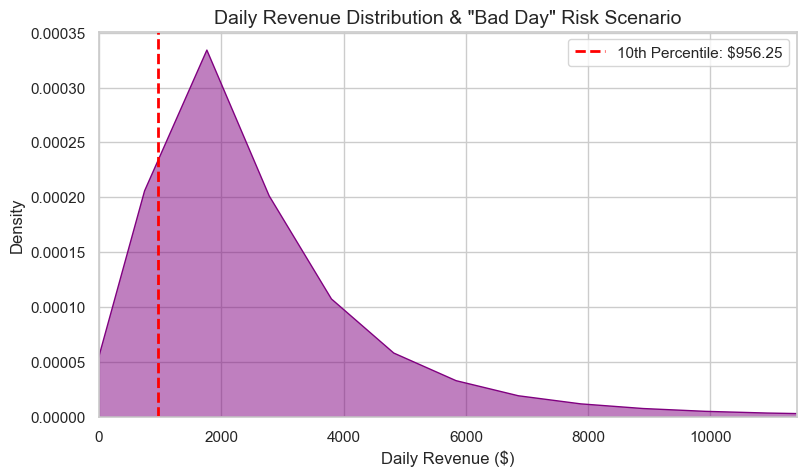

In [46]:
# plotting

plt.figure(figsize=(9, 5))

# Flatten the daily revenue to look at distribution of all simulated days
all_days_rev = daily_revenue.flatten()
sns.kdeplot(all_days_rev, fill=True, color='purple', alpha=0.5)

# 10th percentile marker
bad_day_threshold = np.percentile(all_days_rev, 10)
plt.axvline(bad_day_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'10th Percentile: ${bad_day_threshold:,.2f}')

plt.title('Daily Revenue Distribution & "Bad Day" Risk Scenario', fontsize=14)
plt.xlabel('Daily Revenue ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.xlim(0, np.percentile(all_days_rev, 99)) # Cut off extreme outliers for visibility
plt.show()